# Vase Feature Extraction And Collinearity Workflow
This notebook runs end-to-end extraction, then removes redundant features using correlation-based clustering.

## How To Use
1. Run cells from top to bottom in order.
2. If extraction is already complete, you may skip the extraction cell and begin from the analysis section.
3. Re-run analysis cells after changing thresholds (for example `corr_threshold`).

## What This Notebook Produces
- A compiled feature matrix from raw vase geometry and metadata.
- A reduced (purged) feature set with lower collinearity.
- Diagnostic visualisations to support interpretation and team review.

In [1]:
import importlib
import tqdm as notebook_tqdm
import pandas as pd
from scipy.stats import spearmanr
from scipy.spatial.distance import squareform
import scipy.cluster.hierarchy as sch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
from function_modules.main_extractor import execute_master_pipeline_from_dataframe

/Users/joshmt/theperfectpot_analysis/feature_extraction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
TARGET_SCURVES_DIR = "hubner_lines_0326"
OUTPUT_MATRIX_PATH = "outdir/master_feature_matrix_compiled.csv"
OUTPUT_MATRIX_PARQUET_PATH = "outdir/master_feature_matrix_compiled.parquet"
CHECKPOINT_INTERVAL_SECONDS = 120
BATCH_SIZE = 50
USE_TQDM = True

## Step 1: Run Extraction From Master Parquet

The pipeline expects these columns (mapped automatically if needed):

| Parquet column | Pipeline name |
|---|---|
| `gen` or `generation_key` | `generation` |
| `session_id` | `user_id` |
| `is_selected_vase` | `gen_selected_vase` |
| `vase`, `x`, `y` | (unchanged) |

Any extra columns (`rep`, `rt_tokens`, `model`, etc.) are passed through to the output matrix.

In [ ]:
XY_PARQUET_PATH = "../file_processing/processed/xy_data.parquet"
METADATA_PARQUET_PATH = "../file_processing/processed/metadata.parquet"

master_xy_df = pd.read_parquet(XY_PARQUET_PATH)

master_xy_df["vase_id"] = (
    master_xy_df["user_id"].astype(str)
    + "::"
    + master_xy_df["generation"].astype(str)
    + "::"
    + master_xy_df["vase"].astype(str)
)

print(f"Loaded master parquet: {master_xy_df.shape[0]:,} rows, {master_xy_df.shape[1]} columns")
print("Columns:", list(master_xy_df.columns))

In [4]:
execute_master_pipeline_from_dataframe(
    df=master_xy_df,
    target_dir=TARGET_SCURVES_DIR,
    output_csv_path=OUTPUT_MATRIX_PATH,
    n_jobs=-1,
    prototyping_mode=False,
    resume=False,
    checkpoint_interval_seconds=CHECKPOINT_INTERVAL_SECONDS,
    batch_size=BATCH_SIZE,
    use_tqdm=USE_TQDM,
)

# Convert the CSV output to parquet for compressed storage; CSV is kept as the pipeline's checkpoint artifact
_csv_df = pd.read_csv(OUTPUT_MATRIX_PATH)
_csv_df.to_parquet(OUTPUT_MATRIX_PARQUET_PATH, index=False)

df = pd.read_parquet(OUTPUT_MATRIX_PARQUET_PATH)
print(f"Loaded matrix: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

1. Normalising master dataframe schema (12,487,500 rows)...
2. Loading Standardised Target S-Curves...
3. Partitioning dataset into individual vase profiles...
   Successfully isolated 49950 unique mathematical arrays.
4. Engaging parallel extraction across ALL CPU cores...


Extracting batches (single_csv):   0%|          | 0/999 [00:00<?, ?batch/s][Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done  37 out of  50 | elapsed:    4.9s remaining:    1.7s
[Parallel(n_jobs=-1)]: Done  43 out of  50 | elapsed:    5.5s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    5.6s finished
Extracting batches (single_csv):   0%|          | 1/999 [00:05<1:33:10,  5.60s/batch][Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1

   Checkpoint saved: 1550 rows appended to outdir/master_feature_matrix_compiled.csv.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  37 out of  50 | elapsed:    3.2s remaining:    1.1s
[Parallel(n_jobs=-1)]: Done  43 out of  50 | elapsed:    3.8s remaining:    0.6s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    4.0s finished
Extracting batches (single_csv):   3%|▎         | 32/999 [02:07<1:04:10,  3.98s/batch][Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done  37

   Checkpoint saved: 1300 rows appended to outdir/master_feature_matrix_compiled.csv.


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done  37 out of  50 | elapsed:    3.6s remaining:    1.3s
[Parallel(n_jobs=-1)]: Done  43 out of  50 | elapsed:    4.5s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    4.6s finished
Extracting batches (single_csv):  97%|█████████▋| 967/999 [1:15:22<02:29,  4.68s/batch][Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done  3

   Checkpoint saved: 1350 rows appended to outdir/master_feature_matrix_compiled.csv.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done  37 out of  50 | elapsed:    3.6s remaining:    1.3s
[Parallel(n_jobs=-1)]: Done  43 out of  50 | elapsed:    4.5s remaining:    0.7s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    4.5s finished
Extracting batches (single_csv):  99%|█████████▉| 994/999 [1:17:25<00:22,  4.59s/batch][Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:    1.8s
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]: Done  3

5. Purging corrupted arrays and compiling master matrix...
   Final checkpoint saved: 300 rows appended to outdir/master_feature_matrix_compiled.csv.
6. Output incrementally checkpointed to outdir/master_feature_matrix_compiled.csv.
PIPELINE COMPLETE. Extracted 49950 vases in 77.96 minutes.
Loaded matrix: 49950 rows x 272 columns


,user_id,generation,vase,is_selected,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,adjusted_decision_time_ms,rt_onset_correction_ms,...,SCurve_5_amp_bin_4_iso_crossing_count,SCurve_5_amp_bin_4_mean_curvature,SCurve_5_amp_bin_4_mae,SCurve_5_amp_bin_5_peak_valley_residence,SCurve_5_amp_bin_5_vertical_span,SCurve_5_amp_bin_5_iso_crossing_count,SCurve_5_amp_bin_5_mean_curvature,SCurve_5_amp_bin_5_mae,SCurve_5_amplitude_discontinuity,SCurve_5_srv_elastic_shape_distance
0,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_1,vase_1,0,False,3.963,3963,3.955,3955.0,8.35,...,47,0.415579,1.520702,0.280,0.977885,24,392.425853,1.953860,0,1.227561
1,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_1,vase_2,1,False,3.963,3963,3.955,3955.0,8.35,...,26,7.005101,0.533212,0.160,0.375838,20,180.756219,1.216665,0,1.067292
2,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_2,vase_1,1,True,2.191,2191,2.183,2183.0,8.35,...,26,7.005101,0.533212,0.160,0.375838,20,180.756219,1.216665,0,1.067292
3,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_2,vase_2,0,False,2.191,2191,2.183,2183.0,8.35,...,21,5.225039,0.890404,0.228,0.623722,27,2068.234114,1.550946,0,1.079502
4,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_3,vase_1,1,True,3.323,3323,3.315,3315.0,8.35,...,26,7.005101,0.533212,0.160,0.375838,20,180.756219,1.216665,0,1.067292


In [ ]:
# Retention check: every vase in the input must appear as exactly one row in the output matrix
_input_vase_ids = (
    master_xy_df
    .drop_duplicates(subset=["user_id", "generation", "vase"])
    [["user_id", "generation", "vase"]]
    .assign(vase_id=lambda d: d["user_id"].astype(str) + "::" + d["generation"].astype(str) + "::" + d["vase"].astype(str))
    ["vase_id"]
)
_expected_vases = len(_input_vase_ids)

_output_vase_ids = (
    df["user_id"].astype(str) + "::" + df["generation"].astype(str) + "::" + df["vase"].astype(str)
)

_missing = set(_input_vase_ids) - set(_output_vase_ids)
_extra   = set(_output_vase_ids) - set(_input_vase_ids)

print(f"Expected vases (input) : {_expected_vases:,}")
print(f"Output rows            : {len(_output_vase_ids):,}")
print(f"Missing from output    : {len(_missing)}")
print(f"Unexpected in output   : {len(_extra)}")

if _missing:
    print("\nSample missing vase_ids:")
    for vid in sorted(_missing)[:10]:
        print(f"  {vid}")

# Selection label check
_input_selected  = master_xy_df.drop_duplicates(subset=["user_id", "generation", "vase"])["gen_selected_vase"].sum()
_output_selected = df["is_selected"].sum() if "is_selected" in df.columns else None

if _output_selected is not None:
    print(f"\nSelected vases in input : {int(_input_selected):,}")
    print(f"Selected vases in output: {int(_output_selected):,}")
    if int(_input_selected) != int(_output_selected):
        print("WARNING: selection counts do not match — check label mapping in the pipeline.")
    else:
        print("Selection counts match.")

assert len(_output_vase_ids) == _expected_vases, (
    f"Retention check FAILED: expected {_expected_vases:,} rows, got {len(_output_vase_ids):,}."
)
assert not _missing, (
    f"Retention check FAILED: {len(_missing)} vase(s) present in input but missing from output."
)
print("\nRetention check PASSED.")

In [ ]:
# Diagnostic: how many XY points does each vase profile actually have?
_diag = pd.read_parquet(XY_PARQUET_PATH)
_diag["vase_id"] = (
    _diag["participant_id"].astype(str)
    + "::"
    + _diag["generation_key"].astype(str)
    + "::"
    + _diag["vase"].astype(str)
)
_pts = _diag.groupby('vase_id').size()
print("Points per vase profile:")
print(_pts.value_counts().sort_index().to_string())
print(f"\nTotal unique vase profiles: {len(_pts)}")

Points per vase profile:
250    49950

Total unique vase profiles: 49950
Total number of choices made: 24975.0


In [20]:
# Check the number of participants, and the number of completed rounds per participant
n_participants = _diag['participant_id'].nunique()
n_choices_per_participant = _diag.groupby('participant_id')['generation_key'].nunique()
print(f"Number of unique participants: {n_participants}")
print("Choices made per participant:")
print(n_choices_per_participant.value_counts().sort_index().to_string())

Number of unique participants: 999
Choices made per participant:
generation_key
25    999


## Step 2: Load Compiled Matrix And Prepare Modelling Inputs
This section loads the compiled matrix and splits columns into:
- administrative columns (identifiers and labels), and
- numeric candidate feature columns for statistical filtering.

`X` is the raw numeric feature matrix. `y` is the binary selection target (`is_selected`).

In [21]:
admin_cols = ['user_id', 'generation', 'vase', 'is_selected', 'source_csv']
admin_present = [c for c in admin_cols if c in df.columns]

feature_cols = [c for c in df.columns if c not in admin_cols and pd.api.types.is_numeric_dtype(df[c])]

X = df[feature_cols].copy()
y = df['is_selected'].copy()

print(f"   Initial numerical feature space: {len(X.columns)} dimensions.")

   Initial numerical feature space: 266 dimensions.


In [22]:
# Create a working copy for filtering/cleaning steps
X_filtered = X.copy()

# Handle edge-case numerics before correlation/clustering
X_filtered.replace([np.inf, -np.inf], np.nan, inplace=True)
X_filtered.fillna(0, inplace=True)

# Drop zero-variance features to avoid undefined correlations
var_mask = X_filtered.var(axis=0, ddof=0) > 0
removed_zero_var = int((~var_mask).sum())
X_filtered = X_filtered.loc[:, var_mask]

print(f"Clean feature matrix ready: {X_filtered.shape[0]} rows x {X_filtered.shape[1]} cols")
print(f"Dropped {removed_zero_var} zero-variance features")

Clean feature matrix ready: 49950 rows x 259 cols
Dropped 7 zero-variance features


## Step 3: Clean Features Before Correlation
Before correlation analysis, this step ensures numerical stability by:
- replacing infinities,
- filling missing values, and
- removing zero-variance features (which do not carry discriminative information).

The result is `X_filtered`, the cleaned matrix used by all subsequent clustering steps.

In [23]:
# Calculate non-linear rank correlations
corr_matrix, _ = spearmanr(X_filtered)
corr_df = pd.DataFrame(corr_matrix, columns=X_filtered.columns, index=X_filtered.columns)
corr_df.shape

(259, 259)

## Step 4: Build Correlation Distance And Hierarchical Clusters
This stage converts feature similarity into a clustering structure:
- Spearman correlation captures monotonic relationships between features.
- Distance is computed as `1 - |rho|`, so highly correlated pairs have small distance.
- Complete-linkage hierarchical clustering is then used to group redundant features.

The output of this stage is the linkage matrix `Z` and cluster labels `clusters`.

In [24]:
# Convert Correlation to Distance (1 - |corr|)
distance_matrix = 1 - np.abs(corr_df)
distance_matrix.fillna(1.0, inplace=True) # Max distance for any failed calculations

,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,adjusted_decision_time_ms,rt_onset_correction_ms,rt_calibration_median_ms,rt_calibration_trials_n,play_counter,session_started_at,...,SCurve_5_amp_bin_4_vertical_span,SCurve_5_amp_bin_4_iso_crossing_count,SCurve_5_amp_bin_4_mean_curvature,SCurve_5_amp_bin_4_mae,SCurve_5_amp_bin_5_peak_valley_residence,SCurve_5_amp_bin_5_vertical_span,SCurve_5_amp_bin_5_iso_crossing_count,SCurve_5_amp_bin_5_mean_curvature,SCurve_5_amp_bin_5_mae,SCurve_5_srv_elastic_shape_distance
is_parent_vase,0.000000,0.897744,0.897744,8.985346e-01,8.985346e-01,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.974219,0.927332,0.997558,0.942774,0.987577,0.983261,9.364213e-01,0.966584,0.945234,0.912968
selection_elapsed_time_s,0.897744,0.000000,0.000000,4.969938e-03,4.969938e-03,0.965219,0.933893,0.988330,0.761235,0.953115,...,0.973655,0.978047,0.988432,0.976718,0.976786,0.970319,9.867314e-01,0.990282,0.973842,0.959195
decision_time_ms,0.897744,0.000000,0.000000,4.969938e-03,4.969938e-03,0.965219,0.933893,0.988330,0.761235,0.953115,...,0.973655,0.978047,0.988432,0.976718,0.976786,0.970319,9.867314e-01,0.990282,0.973842,0.959195
adjusted_selection_elapsed_time_s,0.898535,0.004970,0.004970,1.110223e-16,1.110223e-16,0.971811,0.926482,0.905227,0.762374,0.953504,...,0.974645,0.978396,0.988322,0.976934,0.977351,0.970865,9.866494e-01,0.990714,0.974258,0.959192
adjusted_decision_time_ms,0.898535,0.004970,0.004970,1.110223e-16,1.110223e-16,0.971811,0.926482,0.905227,0.762374,0.953504,...,0.974645,0.978396,0.988322,0.976934,0.977351,0.970865,9.866494e-01,0.990714,0.974258,0.959192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SCurve_5_amp_bin_5_vertical_span,0.983261,0.970319,0.970319,9.708646e-01,9.708646e-01,0.996985,0.983133,0.993934,0.999886,0.997249,...,0.325650,0.874295,0.947948,0.897787,0.297532,0.000000,8.957922e-01,0.792904,0.824497,0.706065
SCurve_5_amp_bin_5_iso_crossing_count,0.936421,0.986731,0.986731,9.866494e-01,9.866494e-01,0.990911,0.997909,0.997325,0.988378,0.997064,...,0.852459,0.255748,0.850109,0.805879,0.861961,0.895792,1.110223e-16,0.259993,0.821514,0.323929
SCurve_5_amp_bin_5_mean_curvature,0.966584,0.990282,0.990282,9.907136e-01,9.907136e-01,0.985832,0.996487,0.994779,0.985926,0.996169,...,0.825030,0.433105,0.873430,0.900784,0.965781,0.792904,2.599933e-01,0.000000,0.885531,0.501240
SCurve_5_amp_bin_5_mae,0.945234,0.973842,0.973842,9.742578e-01,9.742578e-01,0.992395,0.993098,0.989594,0.996291,0.993156,...,0.758709,0.783991,0.984924,0.075197,0.828808,0.824497,8.215140e-01,0.885531,0.000000,0.447847


In [25]:
# Compute Complete Linkage (Groups clusters based on maximum distance between their points)
condensed_dist = squareform(distance_matrix.values, checks=False)
Z = sch.linkage(condensed_dist, method='complete')

In [26]:
# Cut the Dendrogram at the specified correlation threshold
corr_threshold = 0.8
dist_threshold = 1.0 - corr_threshold
clusters = sch.fcluster(Z, t=dist_threshold, criterion='distance')

In [27]:
# Map features to their assigned mathematical clusters
cluster_dict = {}
for i, cluster_id in enumerate(clusters):
    if cluster_id not in cluster_dict:
        cluster_dict[cluster_id] = []
    cluster_dict[cluster_id].append(X_filtered.columns[i])

In [28]:
# Isolate the Champion Feature from each cluster
selected_features = []
for c_id, cols in cluster_dict.items():
    if len(cols) == 1:
        selected_features.append(cols[0])
    else:
        # The champion is the one most strongly correlated with human selection
        corrs = [np.abs(X_filtered[col].corr(y)) for col in cols]
        corrs = [0 if np.isnan(c) else c for c in corrs]
        best_col = cols[np.argmax(corrs)]
        selected_features.append(best_col)
        
print(f"Dimensionality collapsed to {len(selected_features)} unique signals.")

Dimensionality collapsed to 112 unique signals.


## Step 5: Select Champion Features Per Cluster
Each collinearity cluster is reduced to one representative feature:
- Single-feature clusters are retained as-is.
- Multi-feature clusters are resolved by choosing the feature with the strongest absolute correlation with `is_selected`.

This yields `selected_features`, the compact signal set used for downstream modelling and interpretation.

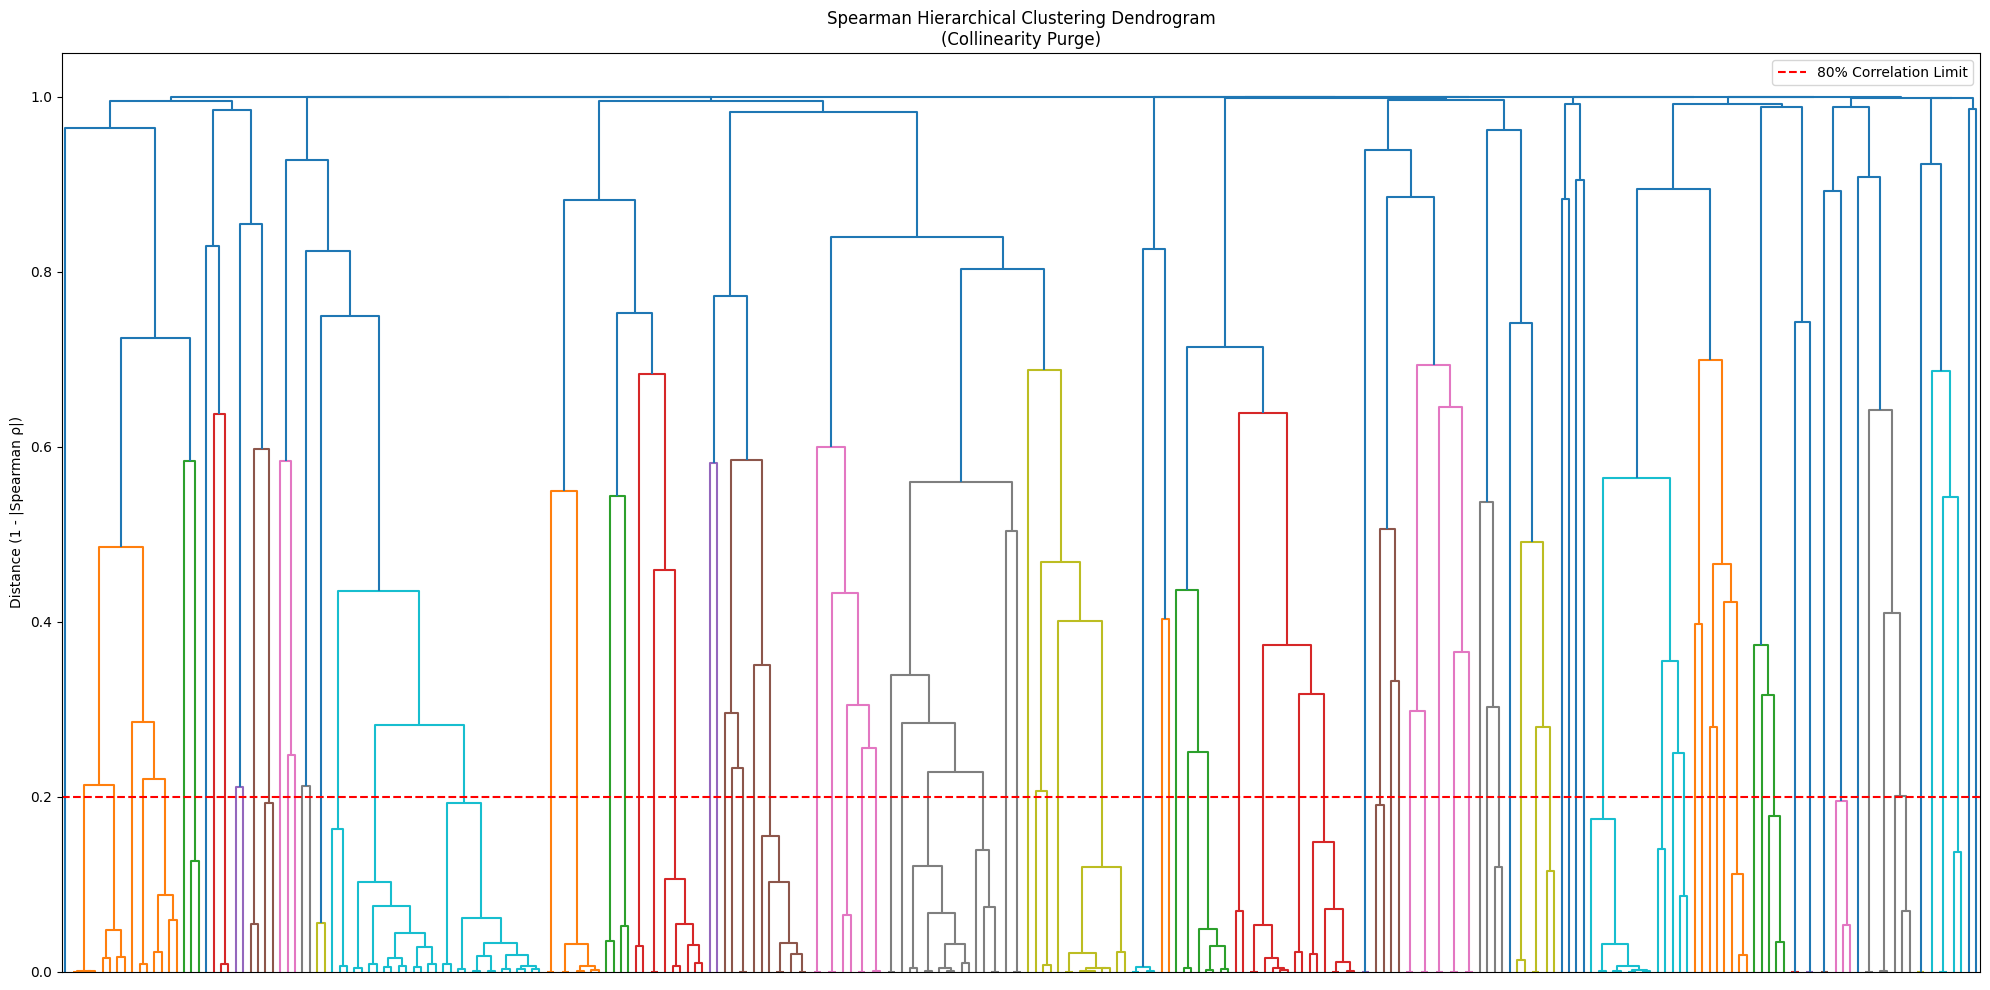

In [30]:
# This dendrogram is purely for visualization and sanity-checking of the clustering results, not for actual feature selection
# It shows the hierarchical relationships between features and where the correlation threshold cut was made, 
# but the actual selection is based on championing within clusters, not on cutting the dendrogram at a specific height
plt.figure(figsize=(20, 10))
sch.dendrogram(Z, labels=X_filtered.columns, leaf_rotation=90, no_labels=True)
plt.axhline(y=dist_threshold, color='r', linestyle='--', label=f'{int(corr_threshold*100)}% Correlation Limit')
plt.title("Spearman Hierarchical Clustering Dendrogram\n(Collinearity Purge)")
plt.ylabel("Distance (1 - |Spearman ρ|)")
plt.legend()
plt.tight_layout()
plt.savefig("plots/dendrogram_purge.png", dpi=300)

In [31]:
biserial_corrs = []
    
# Calculate absolute Point-Biserial correlation for all purged champion features
for col in selected_features:
    corr = X_filtered[col].corr(y)
    if not np.isnan(corr):
        biserial_corrs.append({'Feature': col, 'Biserial_Correlation': np.abs(corr)})
        
df_corrs = pd.DataFrame(biserial_corrs).sort_values(by='Biserial_Correlation', ascending=False).head(20)

/var/folders/q1/fhsbr5cs3nv15vfnqhmblvpr0000gn/T/ipykernel_6722/2544312406.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Biserial_Correlation', y='Feature', data=df_corrs, palette='magma')


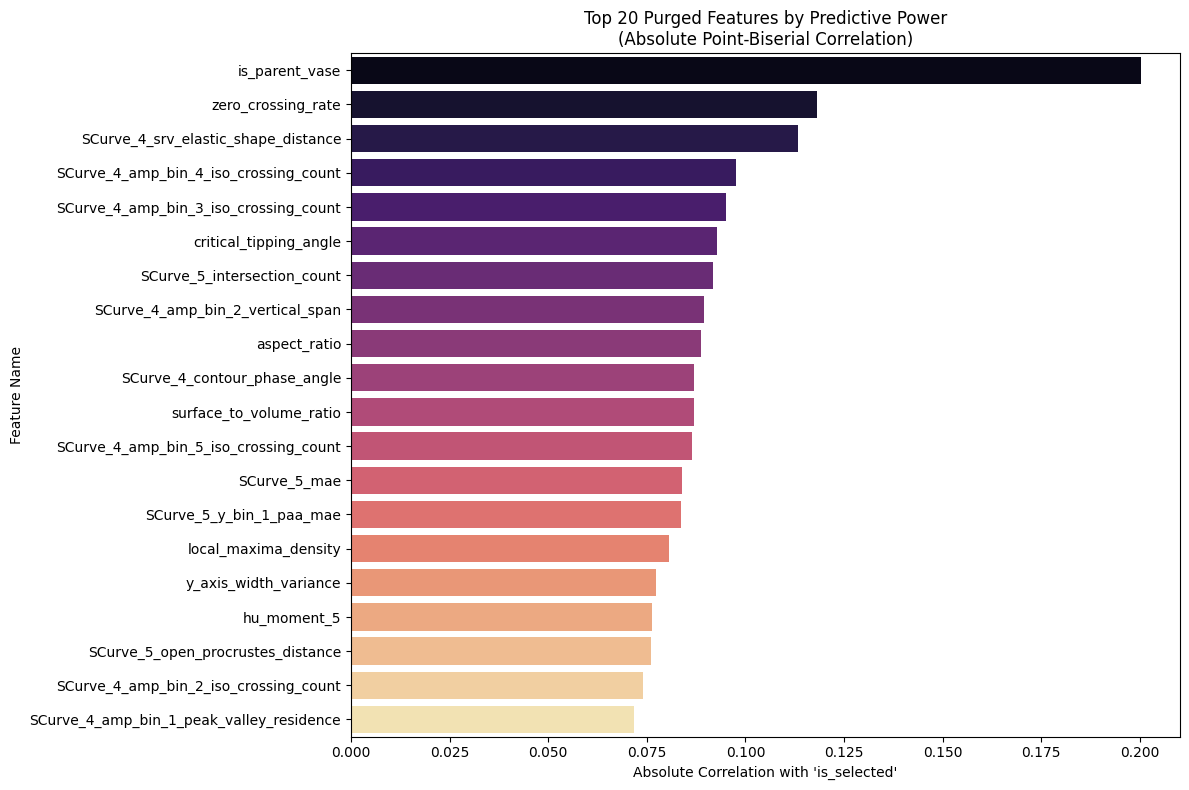

In [32]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Biserial_Correlation', y='Feature', data=df_corrs, palette='magma')
plt.title("Top 20 Purged Features by Predictive Power\n(Absolute Point-Biserial Correlation)")
plt.xlabel("Absolute Correlation with 'is_selected'")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.savefig("plots/top_20_predictive_features.png", dpi=300)

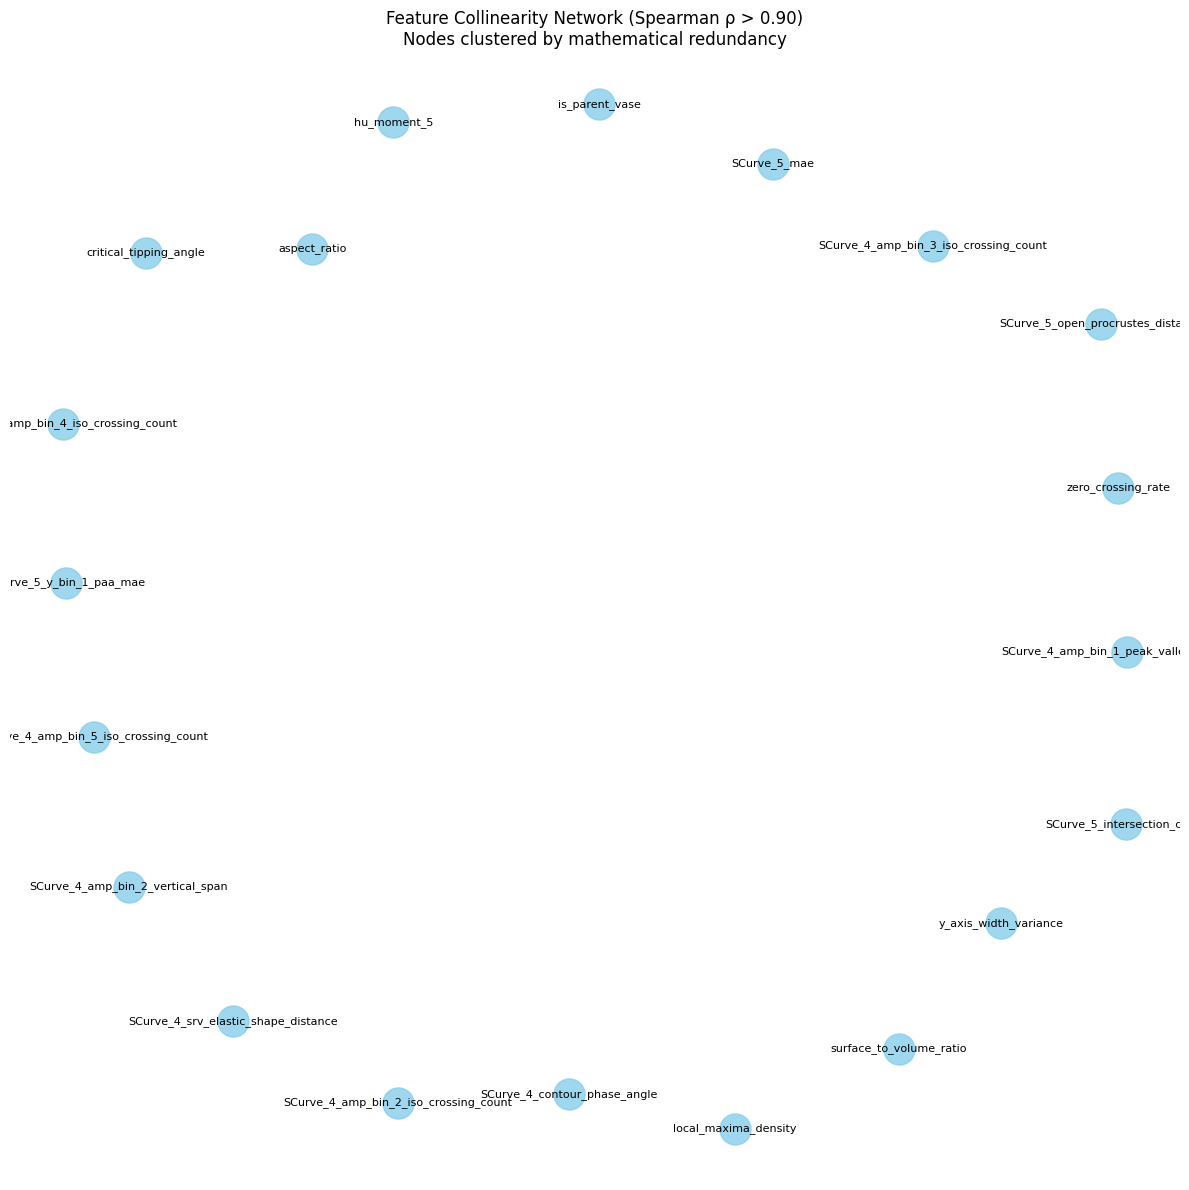

In [33]:
# Isolate the top 30 most predictive features to prevent the graph from becoming an illegible black mass
top_features = df_corrs['Feature'].tolist()[:30] 
X_top = X_filtered[top_features]
corr_top, _ = spearmanr(X_top)

G = nx.Graph()
for f in top_features:
    G.add_node(f)
    
# Draw edges only if the Spearman correlation exceeds the high-risk threshold
for i in range(len(top_features)):
    for j in range(i+1, len(top_features)):
        if np.abs(corr_top[i, j]) > 0.90: 
            G.add_edge(top_features[i], top_features[j], weight=np.abs(corr_top[i, j]))
            
plt.figure(figsize=(12, 12))
# Spring layout physically groups highly connected nodes
pos = nx.spring_layout(G, k=0.5, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=500, node_color='skyblue', alpha=0.8)

edges = G.edges()
weights = [G[u][v]['weight'] * 2 for u,v in edges]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.5)

nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif')

plt.title("Feature Collinearity Network (Spearman ρ > 0.90)\nNodes clustered by mathematical redundancy")
plt.axis('off')
plt.tight_layout()
plt.savefig("plots/collinearity_network.png", dpi=300)

## Step 6: Visualise, Rank, And Export
The final section has three goals:
- Visualise structure: dendrogram and collinearity network plots.
- Rank predictive strength: top champion features by absolute correlation with selection.
- Export deliverables:
  - `master_feature_matrix_purged.csv` (final reduced matrix)
  - saved figures for reporting and team discussion.

Together, these outputs provide both a modelling-ready dataset and an auditable explanation of feature reduction decisions.

In [34]:
final_cols = admin_present + selected_features
df_final = df[final_cols]
df_final.head()

,user_id,generation,vase,is_selected,is_parent_vase,selection_elapsed_time_s,rt_onset_correction_ms,rt_calibration_median_ms,rt_calibration_trials_n,play_counter,...,SCurve_4_amp_bin_4_peak_valley_residence,SCurve_4_amp_bin_4_vertical_span,SCurve_4_amp_bin_4_iso_crossing_count,SCurve_4_amp_bin_4_mean_curvature,SCurve_4_amp_bin_5_peak_valley_residence,SCurve_4_amp_bin_5_vertical_span,SCurve_4_amp_bin_5_iso_crossing_count,SCurve_4_amp_bin_5_mean_curvature,SCurve_5_max_curvature_spatial_deviation,SCurve_5_max_curvature_cross_correlation
0,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_1,vase_1,0,False,3.963,8.35,394.0,8,1,...,0.136,1.151456,47,0.415579,0.280,0.977885,24,392.425853,2.628279,0.361174
1,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_1,vase_2,1,False,3.963,8.35,394.0,8,1,...,0.216,2.325626,26,7.005101,0.160,0.375838,20,180.756219,1.343941,0.410082
2,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_2,vase_1,1,True,2.191,8.35,394.0,8,1,...,0.216,2.325626,26,7.005101,0.160,0.375838,20,180.756219,1.343941,0.410082
3,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_2,vase_2,0,False,2.191,8.35,394.0,8,1,...,0.440,2.368054,21,5.225039,0.228,0.623722,27,2068.234114,1.704291,0.386617
4,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_3,vase_1,1,True,3.323,8.35,394.0,8,1,...,0.216,2.325626,26,7.005101,0.160,0.375838,20,180.756219,1.343941,0.410082


In [36]:
df_final.to_csv("outdir/legacy_master_feature_matrix_purged.csv", index=False)

## Output Guide
This notebook produces several outputs during extraction, feature pruning, and visualization. Use this guide as a quick reference for what each result means.

### 1) `master_feature_matrix_compiled.csv`
- What it is: the full extracted feature matrix before collinearity pruning.
- Rows: one row per vase profile processed from `xy_csv`.
- Columns: administrative identifiers (`user_id`, `generation`, `vase`, `is_selected`, `source_csv`) plus all computed geometric/relational features.
- Typical use: master input for modeling, statistics, and the pruning pipeline below.

### 2) Console Checkpoint + Process Log (`master_feature_matrix_compiled.csv.process_log.csv`)
- What it is: append-only run log generated during extraction.
- Contains: timestamps, file start/complete events, checkpoint writes, and run summaries.
- Typical use: monitor long runs, verify resume behavior, and audit partial progress.

### 3) In-memory matrices created during pruning
- `X`: all numeric feature columns prior to cleanup.
- `X_filtered`: cleaned feature matrix used for clustering/correlation (NaN/inf handled, zero-variance features removed).
- `corr_df`: Spearman feature-to-feature correlation matrix.
- `distance_matrix`: transformed matrix used for clustering, defined as `1 - |correlation|`.
- `Z`: hierarchical linkage output used to define collinearity clusters.

### 4) `dendrogram_purge.png`
- What it is: dendrogram visualization of hierarchical feature clustering.
- Red dashed line: the cut threshold implied by `corr_threshold` (currently 0.90).
- Typical use: sanity-check redundancy structure and threshold behavior.

### 5) Cluster-selection output
- `selected_features`: one representative ("champion") feature per collinearity cluster.
- Champion rule: for multi-feature clusters, chooses the feature with highest absolute correlation to `is_selected`.
- Printed summary: "Dimensionality collapsed to N unique signals."
- Typical use: reduced feature set for interpretable modeling.

### 6) Top predictive feature ranking (`df_corrs`)
- What it is: top 20 champion features ranked by absolute point-biserial-style correlation with `is_selected`.
- Typical use: quick interpretation of strongest univariate signal contributors.

### 7) `top_20_predictive_features.png`
- What it is: bar chart view of `df_corrs` (top 20 predictive purged features).
- Typical use: presentation-ready summary of strongest selected features.

### 8) `collinearity_network.png`
- What it is: network graph among top predictive features where edges indicate very high Spearman collinearity (`|rho| > 0.90`).
- Edge width: strength of collinearity.
- Typical use: visualize residual redundancy among strongest predictors.

### 9) `master_feature_matrix_purged.csv`
- What it is: final reduced matrix with admin columns + `selected_features`.
- Typical use: compact modeling dataset with reduced multicollinearity.

## Step 8: Build Pairwise XGBoost Dataset (Within-Round Vase Deltas)
This step prepares a pairwise training table for XGBoost from the compiled master matrix.

### What it does
- Parses `generation` into `round_num` and `gen_num`.
- For each user-generation choice event, compares the **two vases in that event**.
- Creates pairwise rows as direct feature deltas (`selected - non_selected`) and the reverse direction.
- Writes a new output CSV ready for pairwise ranking models.

In [37]:
PAIRWISE_OUTPUT_PATH = "outdir/pairwise_xgb_within_round_vase_delta_matrix.csv"
PAIRWISE_GROUPS_PATH = "outdir/pairwise_xgb_within_round_vase_delta_group_sizes.csv"

In [38]:
df_final.head()

,user_id,generation,vase,is_selected,is_parent_vase,selection_elapsed_time_s,rt_onset_correction_ms,rt_calibration_median_ms,rt_calibration_trials_n,play_counter,...,SCurve_4_amp_bin_4_peak_valley_residence,SCurve_4_amp_bin_4_vertical_span,SCurve_4_amp_bin_4_iso_crossing_count,SCurve_4_amp_bin_4_mean_curvature,SCurve_4_amp_bin_5_peak_valley_residence,SCurve_4_amp_bin_5_vertical_span,SCurve_4_amp_bin_5_iso_crossing_count,SCurve_4_amp_bin_5_mean_curvature,SCurve_5_max_curvature_spatial_deviation,SCurve_5_max_curvature_cross_correlation
0,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_1,vase_1,0,False,3.963,8.35,394.0,8,1,...,0.136,1.151456,47,0.415579,0.280,0.977885,24,392.425853,2.628279,0.361174
1,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_1,vase_2,1,False,3.963,8.35,394.0,8,1,...,0.216,2.325626,26,7.005101,0.160,0.375838,20,180.756219,1.343941,0.410082
2,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_2,vase_1,1,True,2.191,8.35,394.0,8,1,...,0.216,2.325626,26,7.005101,0.160,0.375838,20,180.756219,1.343941,0.410082
3,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_2,vase_2,0,False,2.191,8.35,394.0,8,1,...,0.440,2.368054,21,5.225039,0.228,0.623722,27,2068.234114,1.704291,0.386617
4,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_3,vase_1,1,True,3.323,8.35,394.0,8,1,...,0.216,2.325626,26,7.005101,0.160,0.375838,20,180.756219,1.343941,0.410082


In [39]:
# 1) Parse round/gen indices from generation labels like round_3_gen_4
pairwise_df = df_final.copy()
if "round" in pairwise_df["generation"].astype(str).str.lower().iloc[0]:
    gen_parts = pairwise_df["generation"].astype(str).str.extract(r"round_(\d+)_gen_(\d+)")
elif "rep" in pairwise_df["generation"].astype(str).str.lower().iloc[0]:
    gen_parts = pairwise_df["generation"].astype(str).str.extract(r"rep_(\d+)_gen_(\d+)")
else:
    gen_parts = pairwise_df["generation"].astype(str).str.extract(r"gen_(\d+)")

if len(gen_parts.columns) < 2:
    gen_parts[1] = gen_parts[0]  # If only one number was extracted, assume it's the generation and set round/rep to 0
    gen_parts[0] = 0
pairwise_df["round_num"] = pd.to_numeric(gen_parts[0], errors="coerce")
pairwise_df["gen_num"] = pd.to_numeric(gen_parts[1], errors="coerce")
pairwise_df = pairwise_df.dropna(subset=["round_num", "gen_num"]).copy()
pairwise_df["round_num"] = pairwise_df["round_num"].astype(int)
pairwise_df["gen_num"] = pairwise_df["gen_num"].astype(int)

pairwise_df.head()

,user_id,generation,vase,is_selected,is_parent_vase,selection_elapsed_time_s,rt_onset_correction_ms,rt_calibration_median_ms,rt_calibration_trials_n,play_counter,...,SCurve_4_amp_bin_4_iso_crossing_count,SCurve_4_amp_bin_4_mean_curvature,SCurve_4_amp_bin_5_peak_valley_residence,SCurve_4_amp_bin_5_vertical_span,SCurve_4_amp_bin_5_iso_crossing_count,SCurve_4_amp_bin_5_mean_curvature,SCurve_5_max_curvature_spatial_deviation,SCurve_5_max_curvature_cross_correlation,round_num,gen_num
0,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_1,vase_1,0,False,3.963,8.35,394.0,8,1,...,47,0.415579,0.280,0.977885,24,392.425853,2.628279,0.361174,0,1
1,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_1,vase_2,1,False,3.963,8.35,394.0,8,1,...,26,7.005101,0.160,0.375838,20,180.756219,1.343941,0.410082,0,1
2,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_2,vase_1,1,True,2.191,8.35,394.0,8,1,...,26,7.005101,0.160,0.375838,20,180.756219,1.343941,0.410082,0,2
3,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_2,vase_2,0,False,2.191,8.35,394.0,8,1,...,21,5.225039,0.228,0.623722,27,2068.234114,1.704291,0.386617,0,2
4,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_3,vase_1,1,True,3.323,8.35,394.0,8,1,...,26,7.005101,0.160,0.375838,20,180.756219,1.343941,0.410082,0,3


In [40]:
# 2) Choose base numeric features to delta between vases within the same choice event
exclude_cols = {
    "user_id", "generation", "vase", "is_selected", "source_csv",
    "round_num", "gen_num", "session_id"
}
base_model_cols = [
    c for c in pairwise_df.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(pairwise_df[c])
]

In [41]:
# 3) Build pairwise rows for same-generation vase choices
# Only keep clean binary choice events with exactly two vases and one selected.
pair_rows = []
group_keys = ["user_id", "generation", "round_num", "gen_num"]
events_seen = 0
events_used = 0
events_skipped = 0

In [42]:
for key, grp in pairwise_df.groupby(group_keys, sort=False):
    events_seen += 1

    if len(grp) != 2:
        events_skipped += 1
        continue

    selected = grp[grp["is_selected"] == 1]
    not_selected = grp[grp["is_selected"] == 0]

    if len(selected) != 1 or len(not_selected) != 1:
        events_skipped += 1
        continue

    events_used += 1
    s = selected.iloc[0]
    n = not_selected.iloc[0]

    d = s[base_model_cols].to_numpy(dtype=float) - n[base_model_cols].to_numpy(dtype=float)
    query_id = f"{key[0]}::{key[1]}"
    delta_cols = [f"vd_{c}" for c in base_model_cols]

    row_pos = {
        "query_id": query_id,
        "user_id": key[0],
        "generation": key[1],
        "round_num": int(key[2]),
        "gen_num": int(key[3]),
        "left_vase": s["vase"],
        "right_vase": n["vase"],
        "label": 1,
    }
    row_pos.update({col: val for col, val in zip(delta_cols, d)})
    pair_rows.append(row_pos)

    row_neg = {
        "query_id": query_id,
        "user_id": key[0],
        "generation": key[1],
        "round_num": int(key[2]),
        "gen_num": int(key[3]),
        "left_vase": n["vase"],
        "right_vase": s["vase"],
        "label": 0,
    }
    row_neg.update({col: -val for col, val in zip(delta_cols, d)})
    pair_rows.append(row_neg)

pairwise_out = pd.DataFrame(pair_rows)

if pairwise_out.empty:
    raise ValueError(
        "No pairwise rows were created. Verify each generation has exactly two vases and one selected label."
    )

print(f"Pairwise dataset created: {pairwise_out.shape[0]} rows x {pairwise_out.shape[1]} columns")
print(f"Events seen: {events_seen}, used: {events_used}, skipped: {events_skipped}")

Pairwise dataset created: 49950 rows x 120 columns
Events seen: 24975, used: 24975, skipped: 0


In [43]:
# Drop non-informative delta columns that are always zero (common for metadata constants).
delta_feature_cols = [c for c in pairwise_out.columns if c.startswith("vd_")]
nonzero_feature_cols = [c for c in delta_feature_cols if not np.isclose(pairwise_out[c].abs().sum(), 0.0)]
keep_cols = [
    "query_id", "user_id", "generation", "round_num", "gen_num",
    "left_vase", "right_vase", "label",
] + nonzero_feature_cols
pairwise_out = pairwise_out[keep_cols].copy()

print(f"Final pairwise dataset: {pairwise_out.shape[0]} rows x {pairwise_out.shape[1]} columns")

Final pairwise dataset: 49950 rows x 113 columns


In [ ]:
pairwise_out.to_csv(PAIRWISE_OUTPUT_PATH, index=False)
group_sizes = pairwise_out.groupby("query_id").size().rename("n_rows").reset_index()
group_sizes.to_csv(PAIRWISE_GROUPS_PATH, index=False)

print(f"Pairwise file written: {PAIRWISE_OUTPUT_PATH}")
print(f"Group-size file written: {PAIRWISE_GROUPS_PATH}")
print(f"Events seen: {events_seen} | used: {events_used} | skipped: {events_skipped}")
print(f"Pairwise shape: {pairwise_out.shape}")
print(f"Unique queries: {group_sizes.shape[0]}")
print(f"Delta features kept: {len(nonzero_feature_cols)}")

# Mirrored pairwise has 2 rows per decision event; decisions = total vases / 2
_expected_decisions = _expected_vases // 2
_expected_mirrored_rows = _expected_decisions * 2
assert len(pairwise_out) == _expected_mirrored_rows, (
    f"Mirrored pairwise FAILED: expected {_expected_mirrored_rows:,} rows "
    f"({_expected_decisions:,} decisions × 2), got {len(pairwise_out):,}."
)
print(f"\nMirrored pairwise check PASSED: {_expected_decisions:,} decisions → {_expected_mirrored_rows:,} rows.")

In [45]:
# Diagnostic: show skipped generation-events and reasons
skip_rows = []
diag_keys = ["user_id", "generation", "round_num", "gen_num"]

In [46]:
pairwise_df.head()

,user_id,generation,vase,is_selected,is_parent_vase,selection_elapsed_time_s,rt_onset_correction_ms,rt_calibration_median_ms,rt_calibration_trials_n,play_counter,...,SCurve_4_amp_bin_4_iso_crossing_count,SCurve_4_amp_bin_4_mean_curvature,SCurve_4_amp_bin_5_peak_valley_residence,SCurve_4_amp_bin_5_vertical_span,SCurve_4_amp_bin_5_iso_crossing_count,SCurve_4_amp_bin_5_mean_curvature,SCurve_5_max_curvature_spatial_deviation,SCurve_5_max_curvature_cross_correlation,round_num,gen_num
0,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_1,vase_1,0,False,3.963,8.35,394.0,8,1,...,47,0.415579,0.280,0.977885,24,392.425853,2.628279,0.361174,0,1
1,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_1,vase_2,1,False,3.963,8.35,394.0,8,1,...,26,7.005101,0.160,0.375838,20,180.756219,1.343941,0.410082,0,1
2,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_2,vase_1,1,True,2.191,8.35,394.0,8,1,...,26,7.005101,0.160,0.375838,20,180.756219,1.343941,0.410082,0,2
3,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_2,vase_2,0,False,2.191,8.35,394.0,8,1,...,21,5.225039,0.228,0.623722,27,2068.234114,1.704291,0.386617,0,2
4,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_3,vase_1,1,True,3.323,8.35,394.0,8,1,...,26,7.005101,0.160,0.375838,20,180.756219,1.343941,0.410082,0,3


In [47]:
for key, grp in pairwise_df.groupby(diag_keys, sort=False):
    n_rows = len(grp)
    n_selected = int((grp["is_selected"] == 1).sum())
    n_not_selected = int((grp["is_selected"] == 0).sum())

    reason = None
    if n_rows != 2:
        reason = f"expected_2_vases_found_{n_rows}"
    elif n_selected != 1 or n_not_selected != 1:
        reason = f"invalid_labels_selected_{n_selected}_not_selected_{n_not_selected}"

    if reason is not None:
        skip_rows.append({
            "user_id": key[0],
            "generation": key[1],
            "round_num": int(key[2]),
            "gen_num": int(key[3]),
            "n_vases": n_rows,
            "n_selected": n_selected,
            "n_not_selected": n_not_selected,
            "reason": reason,
            "vases": ", ".join(sorted(grp["vase"].astype(str).unique())),
        })
        
print(f"Total skipped events: {len(skip_rows)}")

Total skipped events: 0


In [48]:
if skip_rows:
    skipped_events_df = pd.DataFrame(skip_rows).sort_values(["user_id", "round_num", "gen_num"])
else:    skipped_events_df = pd.DataFrame(columns=[
        "user_id", "generation", "round_num", "gen_num",
        "n_vases", "n_selected", "n_not_selected",
        "reason", "vases"
    ])

skipped_events_df.head()

,user_id,generation,round_num,gen_num,n_vases,n_selected,n_not_selected,reason,vases


In [49]:
if skipped_events_df.empty:
    print("No skipped events.")
else:
    display(skipped_events_df)
    display(skipped_events_df["reason"].value_counts().rename_axis("reason").to_frame("count"))

No skipped events.


In [50]:
# Preview the generated pairwise dataset
pairwise_out.head()

,query_id,user_id,generation,round_num,gen_num,left_vase,right_vase,label,vd_is_parent_vase,vd_aspect_ratio,...,vd_SCurve_4_amp_bin_4_peak_valley_residence,vd_SCurve_4_amp_bin_4_vertical_span,vd_SCurve_4_amp_bin_4_iso_crossing_count,vd_SCurve_4_amp_bin_4_mean_curvature,vd_SCurve_4_amp_bin_5_peak_valley_residence,vd_SCurve_4_amp_bin_5_vertical_span,vd_SCurve_4_amp_bin_5_iso_crossing_count,vd_SCurve_4_amp_bin_5_mean_curvature,vd_SCurve_5_max_curvature_spatial_deviation,vd_SCurve_5_max_curvature_cross_correlation
0,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_1,0,1,vase_2,vase_1,1,0.0,0.579910,...,0.080,1.174170,-21.0,6.589522,-0.120,-0.602047,-4.0,-211.669635,-1.284338,0.048908
1,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_1,0,1,vase_1,vase_2,0,-0.0,-0.579910,...,-0.080,-1.174170,21.0,-6.589522,0.120,0.602047,4.0,211.669635,1.284338,-0.048908
2,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_2,0,2,vase_1,vase_2,1,1.0,0.211607,...,-0.224,-0.042428,5.0,1.780061,-0.068,-0.247884,-7.0,-1887.477895,-0.360350,0.023465
3,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_2,0,2,vase_2,vase_1,0,-1.0,-0.211607,...,0.224,0.042428,-5.0,-1.780061,0.068,0.247884,7.0,1887.477895,0.360350,-0.023465
4,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,008e7cb7-6043-458b-870a-f3ec08d461e9,round_0_gen_3,0,3,vase_1,vase_2,1,1.0,-0.432403,...,-0.004,-0.273695,20.0,6.041449,-0.072,-2.096613,14.0,177.911799,1.332434,0.308568


## Step 9: Optimal XGBoost Implementations (In Addition To Current Setup)
This section keeps the existing mirrored pairwise dataset and adds two optimized exports:

1. **Compact Pairwise Classification (one row per choice event)**
   - Uses deterministic vase ordering (`left_vase`, `right_vase`) within each event.
   - Label is `1` if the ordered left vase was selected, else `0`.
   - Feature deltas are `left - right` with prefix `vd_`.

2. **Native XGBoost Ranking Format (`rank:pairwise`)**
   - One row per item (vase), not a delta row.
   - `query_id` groups two rows per event.
   - `label` is relevance (`1` selected, `0` not selected).

This gives you both your current mirrored structure and an efficient/standard ranking-ready alternative.

### Step 9 Output Guide (Delta vs Raw-Value XGBoost)
Use this section as a quick decision guide when running both model families.

#### A) Mirrored Delta Pairwise Dataset (current setup)
- File: `outdir/pairwise_xgb_within_round_vase_delta_matrix.csv`
- Structure: two rows per choice event (selected-minus-rejected and reversed).
- Target column: `label` (1/0).
- Best used for: pairwise **classification** workflows (`binary:logistic`) where you want strict comparison symmetry.

#### B) Compact Delta Pairwise Dataset (optimised delta setup)
- File: `pairwise_xgb_compact_one_row_per_event.csv`
- Structure: one deterministic row per choice event using `left_vase - right_vase`.
- Target column: `left_selected` (1 if left vase was selected, 0 otherwise).
- Best used for: efficient pairwise **classification** with easier data auditing and fewer duplicated rows.

#### C) Raw-Value Rank-Item Dataset (optimised ranking setup)
- File: `xgb_rank_items_within_round.csv`
- Structure: one row per vase item, grouped by `query_id` (typically two rows per event).
- Target column: `relevance` (1 selected, 0 not selected).
- Best used for: native XGBoost **ranking** objective (`rank:pairwise`) and SHAP interpretation on original vase features.

#### Group Files
- `outdir/pairwise_xgb_within_round_vase_delta_group_sizes.csv`
- `pairwise_xgb_compact_group_sizes.csv`
- `xgb_rank_items_within_round_group_sizes.csv`
- These list rows per `query_id` and are useful for validation, diagnostics, and any training pipeline that requires explicit group sizes.

#### Practical Recommendation
- Run both families, as planned:
  - Delta model for comparative decision mechanics.
  - Raw-value rank model for feature-native interpretation and ranking behaviour.
- Compare performance and explanation stability across both to identify robust beauty preference signals.

In [ ]:
# Step 9A) Build a compact one-row-per-event pairwise classification dataset
PAIRWISE_COMPACT_OUTPUT_PATH = "outdir/legacy/pairwise_xgb_compact_one_row_per_event.csv"
PAIRWISE_COMPACT_GROUPS_PATH = "outdir/legacy/pairwise_xgb_compact_group_sizes.csv"

compact_rows = []
compact_skipped = 0

for key, grp in pairwise_df.groupby(group_keys, sort=False):
    if len(grp) != 2:
        compact_skipped += 1
        continue

    selected = grp[grp["is_selected"] == 1]
    not_selected = grp[grp["is_selected"] == 0]
    if len(selected) != 1 or len(not_selected) != 1:
        compact_skipped += 1
        continue

    # Deterministic orientation so we only need one row per event
    ordered = grp.sort_values("vase").reset_index(drop=True)
    left = ordered.iloc[0]
    right = ordered.iloc[1]
    left_selected = int(left["is_selected"] == 1)

    delta = left[base_model_cols].to_numpy(dtype=float) - right[base_model_cols].to_numpy(dtype=float)
    delta_cols = [f"vd_{c}" for c in base_model_cols]

    row = {
        "query_id": f"{key[0]}::{key[1]}",
        "user_id": key[0],
        "generation": key[1],
        "round_num": int(key[2]),
        "gen_num": int(key[3]),
        "left_vase": left["vase"],
        "right_vase": right["vase"],
        "left_selected": left_selected,
    }
    row.update({c: v for c, v in zip(delta_cols, delta)})
    compact_rows.append(row)

pairwise_compact = pd.DataFrame(compact_rows)
if pairwise_compact.empty:
    raise ValueError("Compact pairwise dataset is empty. Check event structure/labels.")

# Drop all-zero delta features
compact_delta_cols = [c for c in pairwise_compact.columns if c.startswith("vd_")]
compact_nonzero = [c for c in compact_delta_cols if not np.isclose(pairwise_compact[c].abs().sum(), 0.0)]
pairwise_compact = pairwise_compact[[
    "query_id", "user_id", "generation", "round_num", "gen_num",
    "left_vase", "right_vase", "left_selected",
] + compact_nonzero].copy()

pairwise_compact.to_csv(PAIRWISE_COMPACT_OUTPUT_PATH, index=False)
pairwise_compact_groups = pairwise_compact.groupby("query_id").size().rename("n_rows").reset_index()
pairwise_compact_groups.to_csv(PAIRWISE_COMPACT_GROUPS_PATH, index=False)

print(f"Compact pairwise file: {PAIRWISE_COMPACT_OUTPUT_PATH}")
print(f"Compact group-size file: {PAIRWISE_COMPACT_GROUPS_PATH}")
print(f"Compact shape: {pairwise_compact.shape}")
print(f"Compact skipped events: {compact_skipped}")
print(f"Compact delta features kept: {len(compact_nonzero)}")

# Compact has exactly 1 row per decision event; decisions = total vases / 2
assert len(pairwise_compact) == _expected_decisions, (
    f"Compact pairwise FAILED: expected {_expected_decisions:,} rows (one per decision), "
    f"got {len(pairwise_compact):,}."
)
print(f"\nCompact pairwise check PASSED: {_expected_decisions:,} decisions → {len(pairwise_compact):,} rows.")

In [53]:
# Step 9A diagnostics: which compact delta features were dropped and why
compact_dropped_features = sorted(set(compact_delta_cols) - set(compact_nonzero))

compact_drop_report = pd.DataFrame({
    "feature": compact_dropped_features,
    "reason": "Absolute sum across all events is 0 (no variation in compact left-right deltas).",
})

print(f"Compact features dropped: {len(compact_dropped_features)}")
if compact_drop_report.empty:
    print("No compact delta features were dropped.")
else:
    display(compact_drop_report)

Compact features dropped: 7


,feature,reason
0,vd_play_counter,Absolute sum across all events is 0 (no variat...
1,vd_rt_calibration_median_ms,Absolute sum across all events is 0 (no variat...
2,vd_rt_calibration_trials_n,Absolute sum across all events is 0 (no variat...
3,vd_rt_onset_correction_ms,Absolute sum across all events is 0 (no variat...
4,vd_selection_elapsed_time_s,Absolute sum across all events is 0 (no variat...
5,vd_session_duration_s,Absolute sum across all events is 0 (no variat...
6,vd_session_started_at,Absolute sum across all events is 0 (no variat...


In [ ]:
# Step 9B) Build native item-level ranking dataset for XGBoost rank:pairwise
RANK_ITEMS_OUTPUT_PATH = "outdir/legacy/xgb_rank_items_within_round.csv"
RANK_GROUPS_OUTPUT_PATH = "outdir/legacy/xgb_rank_items_within_round_group_sizes.csv"

rank_rows = []
rank_skipped = 0

for key, grp in pairwise_df.groupby(group_keys, sort=False):
    if len(grp) != 2:
        rank_skipped += 1
        continue

    selected = grp[grp["is_selected"] == 1]
    not_selected = grp[grp["is_selected"] == 0]
    if len(selected) != 1 or len(not_selected) != 1:
        rank_skipped += 1
        continue

    qid = f"{key[0]}::{key[1]}"
    for _, r in grp.iterrows():
        row = {
            "query_id": qid,
            "user_id": key[0],
            "generation": key[1],
            "round_num": int(key[2]),
            "gen_num": int(key[3]),
            "vase": r["vase"],
            "relevance": int(r["is_selected"]),
        }
        for c in base_model_cols:
            row[c] = r[c]
        rank_rows.append(row)

rank_items = pd.DataFrame(rank_rows)
if rank_items.empty:
    raise ValueError("Ranking item-level dataset is empty. Check event structure/labels.")

# Drop all-zero numeric item features
rank_numeric_features = [c for c in base_model_cols if c in rank_items.columns]
rank_nonzero = [c for c in rank_numeric_features if not np.isclose(rank_items[c].abs().sum(), 0.0)]
rank_items = rank_items[[
    "query_id", "user_id", "generation", "round_num", "gen_num", "vase", "relevance",
] + rank_nonzero].copy()

rank_items.to_csv(RANK_ITEMS_OUTPUT_PATH, index=False)
rank_groups = rank_items.groupby("query_id").size().rename("n_rows").reset_index()
rank_groups.to_csv(RANK_GROUPS_OUTPUT_PATH, index=False)

print(f"Rank-item file: {RANK_ITEMS_OUTPUT_PATH}")
print(f"Rank-item group-size file: {RANK_GROUPS_OUTPUT_PATH}")
print(f"Rank-item shape: {rank_items.shape}")
print(f"Rank-item skipped events: {rank_skipped}")
print(f"Rank-item features kept: {len(rank_nonzero)}")

# Rank-item has 2 rows per decision event (one per vase); decisions = total vases / 2
_expected_rank_rows = _expected_vases  # 2 items × (vases/2) decisions = vases
assert len(rank_items) == _expected_rank_rows, (
    f"Rank-item FAILED: expected {_expected_rank_rows:,} rows "
    f"({_expected_decisions:,} decisions × 2 items), got {len(rank_items):,}."
)
print(f"\nRank-item check PASSED: {_expected_decisions:,} decisions → {len(rank_items):,} rows.")

In [56]:
# Step 9B diagnostics: which raw-value rank features were dropped and why
rank_dropped_features = sorted(set(rank_numeric_features) - set(rank_nonzero))

rank_drop_report = pd.DataFrame({
    "feature": rank_dropped_features,
    "reason": "Absolute sum across all ranking rows is 0 (no variation / constant zero feature).",
})

print(f"Rank-item features dropped: {len(rank_dropped_features)}")
if rank_drop_report.empty:
    print("No rank-item features were dropped.")
else:
    display(rank_drop_report)

Rank-item features dropped: 0
No rank-item features were dropped.
